In [347]:
import numpy as np
import pandas as pd
from scipy import stats

from v2_data_preparation import slice_by_dates, handle_missing_values, load_and_prepare_data, process_insitu

##### Normalizacion de observaciones SAR con angulo constante

In [348]:
# beta unificado entre orbitas

df = pd.read_csv("../data/processed/satellites/SDH1_S1_2014-10_2026-09_Mono_Lee_12x12_dB.csv")

# 1. Asegurar tipo numérico y filtrar filas con NaN o infinitos en las columnas clave
df['angle'] = pd.to_numeric(df['angle'], errors='coerce')
df['VV'] = pd.to_numeric(df['VV'], errors='coerce')

# Máscara de datos válidos para el ajuste
valid_mask = df['angle'].notna() & df['VV'].notna() & np.isfinite(df['angle']) & np.isfinite(df['VV'])

# 2. Calcular la pendiente usando solo datos válidos
beta, intercept = np.polyfit(df.loc[valid_mask, 'angle'], df.loc[valid_mask, 'VV'], deg=1)
print(f"Pendiente constante (beta) estimada: {beta:.4f} dB/Grado")
print(f"Intercepto estimado: {intercept:.4f} dB")

# 3. Definir el ángulo de referencia
ref_angle = 38.5

# 4. Aplicar la ecuación de normalización (los NaN se mantendrán como NaN sin romper el cálculo)
col_name = f'VV_{ref_angle}'
df[col_name] = df['VV'] - beta * (df['angle'] - ref_angle)

# Visualizar el resultado omitiendo NaN
print(df[['Timestamps', 'angle', 'VV', col_name]].dropna().head())

Pendiente constante (beta) estimada: -0.2889 dB/Grado
Intercepto estimado: -3.8956 dB
   Timestamps      angle         VV    VV_38.5
0  2014-10-16  44.856255 -16.847290 -15.011060
1  2015-05-13  32.494759 -13.797065 -15.531893
2  2015-05-20  44.844391 -17.020372 -15.187569
3  2016-02-13  32.634712 -11.930467 -13.624864
4  2016-02-20  44.770618 -12.648417 -10.836926


##### Resampleo semanal SAR

In [349]:
df["Timestamps"] = pd.to_datetime(df["Timestamps"], format="%Y-%m-%d")

In [350]:
df_cleaned = df.drop_duplicates(
    subset=["Timestamps"], keep="first").set_index(
        "Timestamps").sort_index()

In [351]:
df_cleaned

,orbit,angle,VV,VH,VV_38.5
Timestamps,,,,,
2014-10-16,DESCENDING,44.856255,-16.847290,-24.375688,-15.011060
2015-05-13,DESCENDING,32.494759,-13.797065,-23.784230,-15.531893
2015-05-20,DESCENDING,44.844391,-17.020372,-24.280121,-15.187569
2016-02-13,DESCENDING,32.634712,-11.930467,-24.662094,-13.624864
2016-02-20,DESCENDING,44.770618,-12.648417,-22.515573,-10.836926
...,...,...,...,...,...
2026-09-02,DESCENDING,44.935013,-16.043410,-26.531136,-14.184427
2026-09-07,ASCENDING,37.650482,-11.241912,-23.418307,-11.487326
2026-09-08,DESCENDING,44.769836,-14.256156,-31.149520,-12.444891


In [352]:
# Convertir dB a escala lineal antes de resamplear
# lineal = 10^(dB / 10)
df_cleaned['VV_linear'] = 10 ** (df_cleaned[col_name] / 10)

# Reindexar a frecuencia semanal
df_weekly = df_cleaned[['VV_linear']].resample('W').mean()

df_weekly

,VV_linear
Timestamps,
2014-10-19,0.031542
2014-10-26,NaN
2014-11-02,NaN
2014-11-09,NaN
2014-11-16,NaN
...,...
2026-08-23,0.042742
2026-08-30,0.068326
2026-09-06,0.046340


In [353]:
df_weekly_clip = (
    slice_by_dates(df_weekly, '2017-02', '2026-07-05')
    .pipe(handle_missing_values, method='time')
)

In [354]:
df_weekly_clip

,VV_linear
Timestamps,
2017-02-05,0.039321
2017-02-12,0.031556
2017-02-19,0.038549
2017-02-26,0.045541
2017-03-05,0.035185
...,...
2026-06-07,0.033424
2026-06-14,0.025457
2026-06-21,0.015987


In [355]:
# Volver a convertir el promedio semanal a dB
df_weekly_clip[f'{col_name}_weekly'] = 10 * np.log10(df_weekly_clip['VV_linear'])

# Eliminar columna auxiliar lineal
s1_weekly = df_weekly_clip.drop(columns=['VV_linear'])

In [356]:
s1_weekly_2 = slice_by_dates(s1_weekly, '2024')

<Axes: xlabel='Timestamps'>

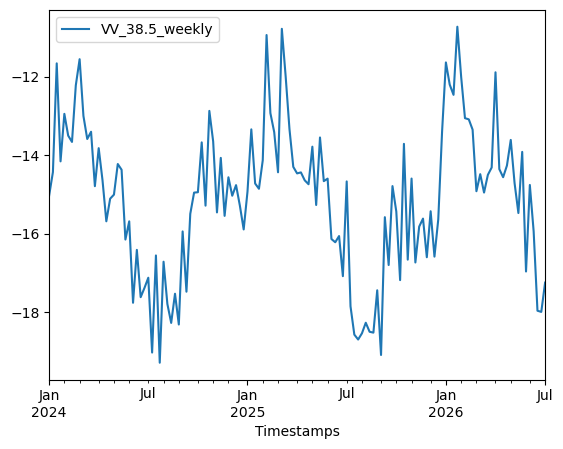

In [357]:
s1_weekly_2.plot()

##### Resampleo observaciones 2024-2026

In [358]:
insitu = process_insitu(
    filepath='../data/processed/in-situ/SDH1_daily-insitu-data.csv',
    start_date='2024-05-22',
    end_date='2026-05-14',
    cols_to_keep=['SDH1PS01_gw-depth_m', 'ATMOS41_precipitation_mm'],
    outlier_threshold=3,
    ignore_outliers_cols=['ATMOS41_precipitation_mm']
)

In [359]:
insitu_weekly = insitu.resample('W').agg({
    'SDH1PS01_gw-depth_m': 'mean',
    'ATMOS41_precipitation_mm': 'sum'
})

In [360]:
daily_df = insitu.join(df_cleaned, how='outer')
daily_df = slice_by_dates(daily_df, '2024-05-22', '2026-05-14')

In [361]:
daily_df

,SDH1PS01_gw-depth_m,ATMOS41_precipitation_mm,orbit,angle,VV,VH,VV_38.5,VV_linear
2024-05-22,-0.601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-23,-0.601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-24,-0.604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-25,-0.610,NaN,DESCENDING,32.683262,-14.714466,-30.068978,-16.394838,0.022936
2024-05-26,-0.619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2026-05-10,-0.599,0.0,DESCENDING,44.795349,-16.981513,-25.871474,-15.162878,0.030459
2026-05-11,-0.599,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-12,-0.591,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-13,-0.580,0.0,NaN,NaN,NaN,NaN,NaN,NaN


Probabré primero a filtrar las semanas con precipitaciones. Si no tengo buenos resultados, podría probar a filtrar los días + n siguientes con lluvias y luego hacer el resampleo.

Una vez que elimine las semanas con precipitaciones, no puedo dejar nan porque falla la correlación cruzada ¿cual es la mejor opcion? ¿rellenar con el valor promedio? ¿normalizar y rellenar con 0 (media)?

In [362]:
def subset_by_meteo(df, min_pp = 0.0):
    """
    Subdivide un df en funcion de condiciones meteorologicas
    """
    # Establece condicion
    rained = df['ATMOS41_precipitation_mm'] > min_pp

    # Divide los df con la mascara
    rain = df[rained]
    no_rain = df[~rained]

    return rain, no_rain

In [363]:
insitu_weekly_rain, insitu_weekly_no_rain = subset_by_meteo(insitu_weekly, 0.0)

<Axes: >

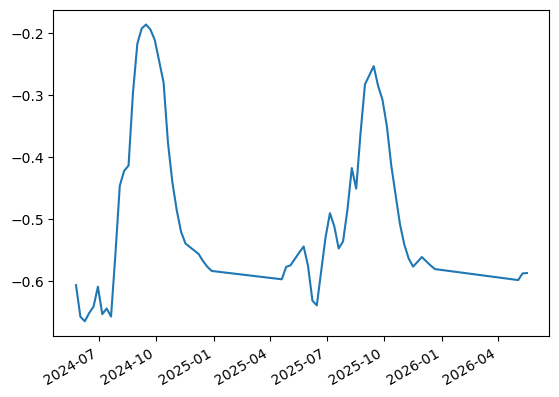

In [364]:
insitu_weekly_no_rain['SDH1PS01_gw-depth_m'].plot()

<Axes: >

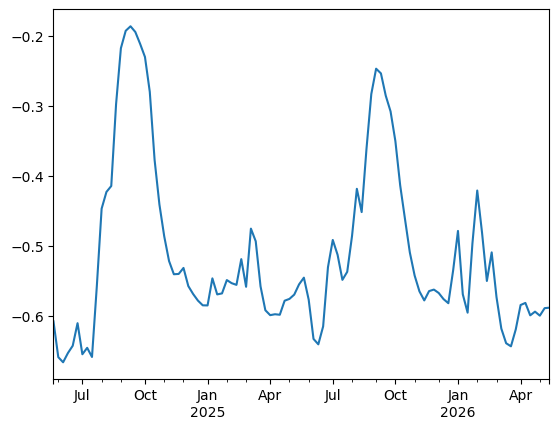

In [365]:
insitu_weekly['SDH1PS01_gw-depth_m'].plot()

<Axes: >

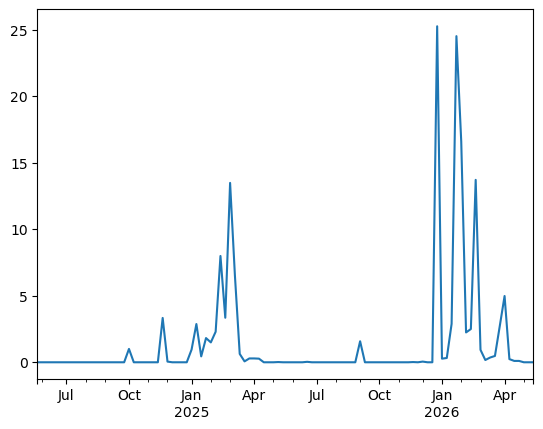

In [366]:
insitu_weekly['ATMOS41_precipitation_mm'].plot()

In [367]:
fp1 = '../outputs/predictions/SDH1_2000-2026_first-year.csv'
modeled1 = load_and_prepare_data(fp1)

# Reindexar a frecuencia semanal
modeled1_weekly = modeled1[['predicted']].resample('W').mean()

# Clipear al rango S1
modeled1_weekly = slice_by_dates(modeled1_weekly, '2017-02')

#### Correlaciones cruzadas

In [368]:
def cross_correlation_xbh(x, y, max_lag, alpha=0.05):
    """
    Calcula la correlación cruzada y los umbrales críticos de significación 
    siguiendo el método xBH de Gao et al. (2024).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    N = len(x)
    
    if len(y) != N:
        raise ValueError("Las series x e y deben tener la misma longitud N.")
    
    # 1. Estandarización (desmedido y escala)
    x_c = x - np.mean(x)
    y_c = y - np.mean(y)
    
    std_x = np.std(x_c, ddof=0)
    std_y = np.std(y_c, ddof=0)
    
    # 2. Autocorrelaciones muestrales completas
    autocorr_x = np.correlate(x_c, x_c, mode='full')[N-1:] / (N * std_x**2)
    autocorr_y = np.correlate(y_c, y_c, mode='full')[N-1:] / (N * std_y**2)
    
    lags = np.arange(-max_lag, max_lag + 1)
    n_tau = len(lags)
    
    ccf = np.zeros(n_tau)
    delta = np.zeros(n_tau)
    v_eff = np.zeros(n_tau)
    rho_c = np.zeros(n_tau)
    
    # 3. Cálculo de CCF y delta(tau) para cada lag
    for idx, tau in enumerate(lags):
        abs_tau = abs(tau)
        N_sub = N - abs_tau
        
        if tau >= 0:
            cxy = np.sum(x_c[:N_sub] * y_c[tau:]) / N
        else:
            cxy = np.sum(x_c[abs_tau:] * y_c[:N_sub]) / N
            
        ccf[idx] = cxy / (std_x * std_y)
        
        # Factor xBH: Ec. (5)
        k = np.arange(1, N_sub)
        weight = (N_sub - k) / N_sub
        sum_term = np.sum(weight * autocorr_x[k] * autocorr_y[k])
        
        denom = 1.0 + 2.0 * sum_term
        delta[idx] = 1.0 / denom if denom > 0 else 0.0
        
        # Grados de libertad efectivos: Ec. (4)
        v_eff[idx] = max(N_sub * delta[idx] - 2.0, 1.0)
        
    # 4. Ajuste por búsqueda de rango: Ecs. (6) y (7)
    delta_0 = delta[n_tau // 2]  # delta en tau = 0
    n_i = max(n_tau * delta_0, 1.0)
    alpha_c = 1.0 - (1.0 - alpha)**(1.0 / n_i)
    
    # 5. Coeficiente crítico para cada tau: Ec. (8)
    for idx, tau in enumerate(lags):
        abs_tau = abs(tau)
        t_crit = stats.t.ppf(1.0 - alpha_c / 2.0, df=v_eff[idx])
        rho_c[idx] = ((N - abs_tau) / N) * (t_crit / np.sqrt(v_eff[idx] + t_crit**2))
        
    # Identificar si la correlación observada es significativa
    is_significant = np.abs(ccf) >= rho_c
    
    return {
        'lags': lags,
        'ccf': ccf,
        'rho_critical': rho_c,
        'is_significant': is_significant,
        'v_effective': v_eff,
        'delta': delta,
        'n_independent': n_i,
        'alpha_adjusted': alpha_c
    }

In [377]:
modeled1_weekly['predicted']

Timestamps
2017-02-05   -0.551883
2017-02-12   -0.566222
2017-02-19   -0.581173
2017-02-26   -0.581626
2017-03-05   -0.576405
                ...   
2026-06-07   -0.558070
2026-06-14   -0.514707
2026-06-21   -0.519307
2026-06-28   -0.512028
2026-07-05   -0.523783
Freq: W-SUN, Name: predicted, Length: 492, dtype: float64

In [371]:
s1_weekly['VV_38.5_weekly']

Timestamps
2017-02-05   -14.053725
2017-02-12   -15.009184
2017-02-19   -14.139905
2017-02-26   -13.415937
2017-03-05   -14.536372
                ...    
2026-06-07   -14.759384
2026-06-14   -15.941925
2026-06-21   -17.962255
2026-06-28   -17.992391
2026-07-05   -17.245992
Freq: W-SUN, Name: VV_38.5_weekly, Length: 492, dtype: float64

##### Iteración 1: backscatter normalizado a 38.5° y nivel modelado (2017-2026)

In [372]:
res = cross_correlation_xbh(s1_weekly['VV_38.5_weekly'], modeled1_weekly['predicted'], max_lag=10, alpha=0.05)
    
print(f"Número de desfases independientes (n_i): {res['n_independent']:.2f}")
print(f"Alpha ajustado por búsqueda de rango (alpha_c): {res['alpha_adjusted']:.4f}")
print(f"Picos con correlación significativa: {np.sum(res['is_significant'])} de {len(res['lags'])}")

lags = res['lags']
ccf = res['ccf']
sig_mask = res['is_significant']

if np.any(sig_mask):
    # Índices de los lags significativos
    sig_indices = np.where(sig_mask)[0]
    
    # Índice del lag significativo con la mayor correlación absoluta
    best_idx = sig_indices[np.argmax(np.abs(ccf[sig_indices]))]
    
    optimal_lag = lags[best_idx]
    optimal_ccf = ccf[best_idx]
    crit_val = res['rho_critical'][best_idx]
    
    print(f"Lag óptimo: {optimal_lag}")
    print(f"CCF observada: {optimal_ccf:.4f} (Umbral crítico: ±{crit_val:.4f})")
else:
    print("No se encontró ningún lag estadísticamente significativo.")


Número de desfases independientes (n_i): 1.05
Alpha ajustado por búsqueda de rango (alpha_c): 0.0475
Picos con correlación significativa: 7 de 21
Lag óptimo: 8
CCF observada: -0.5296 (Umbral crítico: ±0.3987)


In [373]:
res

{'lags': array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 'ccf': array([ 0.1057282 ,  0.09173796,  0.09291473,  0.09010036,  0.09372986,
         0.10372933,  0.08964653,  0.07478024,  0.04100974,  0.01249038,
        -0.0397817 , -0.14540112, -0.24004886, -0.33378379, -0.40765315,
        -0.46435044, -0.50567878, -0.5199698 , -0.52964199, -0.50144679,
        -0.47701603]),
 'rho_critical': array([0.397644  , 0.39815543, 0.39866618, 0.39917626, 0.39968567,
        0.40019442, 0.40070251, 0.40120994, 0.40171671, 0.40222283,
        0.4027283 , 0.40222283, 0.40171671, 0.40120994, 0.40070251,
        0.40019442, 0.39968567, 0.39917626, 0.39866618, 0.39815543,
        0.397644  ]),
 'is_significant': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True,  True,  True,  True,
         True,  True,  True]),
 'v_effective': array([22.29640275, 22.3340785

##### Iteración 2: backscatter y nivel observado con pp removidas por método de ortogonalización

In [374]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. Alinear datasets por DateTimeIndex y eliminar semanas sin coincidencia
df = pd.concat([
    s1_weekly['VV_38.5_weekly'],
    insitu_weekly[['SDH1PS01_gw-depth_m', 'ATMOS41_precipitation_mm']]
], axis=1).dropna()

# 2. Construcción de matrices
N = len(df)
x = df['VV_38.5_weekly'].to_numpy(dtype=float)
y = df['SDH1PS01_gw-depth_m'].to_numpy(dtype=float)
precip = df['ATMOS41_precipitation_mm'].to_numpy(dtype=float)

# Matriz de proyección ortogonal M_Z
Z = np.column_stack([np.ones(N), precip])
# Proyección de x e y sobre el complemento ortogonal de Z
# M_Z * v = v - Z * (Z^T Z)^(-1) * Z^T * v
beta_x, _, _, _ = np.linalg.lstsq(Z, x, rcond=None)
beta_y, _, _, _ = np.linalg.lstsq(Z, y, rcond=None)

x_star = x - Z @ beta_x
y_star = y - Z @ beta_y

# Verificación matemática (las correlaciones con la lluvia deben ser ~0)
corr_x_precip = np.corrcoef(x_star, precip)[0, 1]
corr_y_precip = np.corrcoef(y_star, precip)[0, 1]
print(f"Correlación residual x* con precipitación: {corr_x_precip:.2e}")
print(f"Correlación residual y* con precipitación: {corr_y_precip:.2e}")

# 3. Ejecutar cross_correlation_xbh sobre las series ortogonalizadas
res2 = cross_correlation_xbh(x_star, y_star, max_lag=10, alpha=0.05)

# 4. Extracción y evaluación del lag óptimo
lags = res2['lags']
ccf = res2['ccf']
sig_mask = res2['is_significant']

if np.any(sig_mask):
    sig_indices = np.where(sig_mask)[0]
    best_idx = sig_indices[np.argmax(np.abs(ccf[sig_indices]))]
    
    print(f"\nLag óptimo: {lags[best_idx]} semanas")
    print(f"CCF observada: {ccf[best_idx]:.4f}")
    print(f"Umbral crítico: ±{res2['rho_critical'][best_idx]:.4f}")
    print(f"Grados de libertad efectivos (nu): {res2['v_effective'][best_idx]:.1f}")
else:
    print("\nNo se encontraron desfases significativos tras remover el componente lineal de la precipitación.")


Correlación residual x* con precipitación: 3.28e-16
Correlación residual y* con precipitación: 2.36e-16

Lag óptimo: 6 semanas
CCF observada: -0.6158
Umbral crítico: ±0.5719
Grados de libertad efectivos (nu): 13.1


In [375]:
res2

{'lags': array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 'ccf': array([ 0.15245574,  0.16061241,  0.17482748,  0.17736685,  0.19267344,
         0.16710222,  0.09620385,  0.0472359 , -0.00285948, -0.06429427,
        -0.17456179, -0.32338245, -0.40087082, -0.46407333, -0.52009234,
        -0.57799413, -0.61582923, -0.60277624, -0.59174994, -0.54389507,
        -0.48699721]),
 'rho_critical': array([0.55697661, 0.56075198, 0.56449972, 0.56822177, 0.57191901,
        0.57559244, 0.57924269, 0.58287049, 0.58647638, 0.59006079,
        0.59362411, 0.59006079, 0.58647638, 0.58287049, 0.57924269,
        0.57559244, 0.57191901, 0.56822177, 0.56449972, 0.56075198,
        0.55697661]),
 'is_significant': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True,  True,  True,
         True, False, False]),
 'v_effective': array([12.64443604, 12.7645964

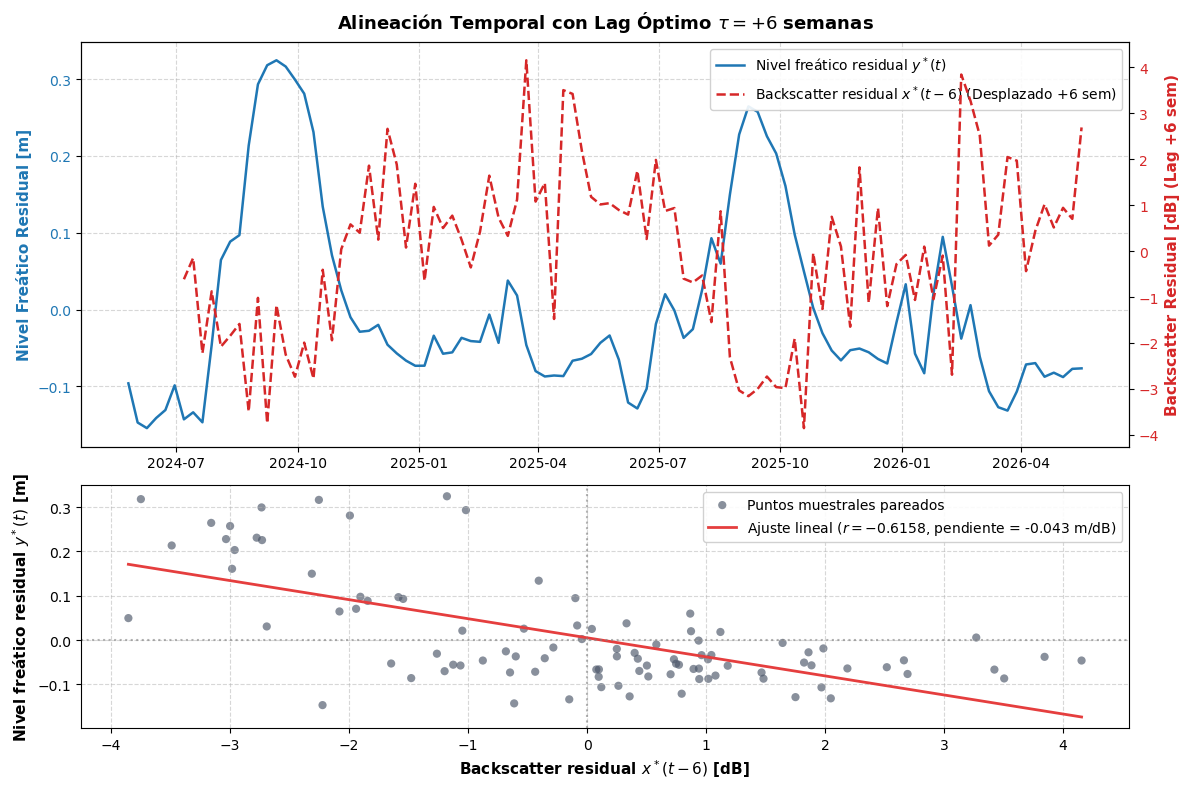

In [376]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Crear un DataFrame con las series ortogonalizadas (o las originales)
# Usando el índice temporal común obtenido en el paso de ortogonalización
df_aligned = pd.DataFrame({
    'water_table_res': y_star,    # Nivel freático residual [m]
    'backscatter_res': x_star     # Backscatter residual [dB]
}, index=df.index)

# 2. Aplicar el desplazamiento de 6 semanas al backscatter
LAG_OPT = 6
df_aligned['backscatter_shifted'] = df_aligned['backscatter_res'].shift(LAG_OPT)

# 3. Configuración de la figura (2 paneles: Serie Temporal y Dispersión)
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(12, 8), 
    gridspec_kw={'height_ratios': [2, 1.2]}
)

# --- PANEL 1: SERIES TEMPORALES ALINEADAS (DOBLE EJE Y) ---
color_gw = '#1f77b4'   # Azul para nivel freático
color_s1 = '#d62728'   # Rojo para Sentinel-1

# Eje izquierdo: Nivel freático
ax1.plot(
    df_aligned.index, 
    df_aligned['water_table_res'], 
    color=color_gw, 
    linewidth=1.8, 
    label=r'Nivel freático residual $y^*(t)$'
)
ax1.set_ylabel('Nivel Freático Residual [m]', color=color_gw, fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_gw)
ax1.grid(True, linestyle='--', alpha=0.5)

# Eje derecho: Backscatter desplazado +6 semanas
ax1_twin = ax1.twinx()
ax1_twin.plot(
    df_aligned.index, 
    df_aligned['backscatter_shifted'], 
    color=color_s1, 
    linestyle='--', 
    linewidth=1.8, 
    label=rf'Backscatter residual $x^*(t - {LAG_OPT})$ (Desplazado +{LAG_OPT} sem)'
)
ax1_twin.set_ylabel(f'Backscatter Residual [dB] (Lag +{LAG_OPT} sem)', color=color_s1, fontsize=11, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor=color_s1)

# Leyenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9)
ax1.set_title(rf'Alineación Temporal con Lag Óptimo $\tau = +{LAG_OPT}$ semanas', fontsize=13, fontweight='bold', pad=10)

# --- PANEL 2: SCATTER PLOT Y RECTA DE AJUSTE LINEAL ---
df_pairs = df_aligned[['backscatter_shifted', 'water_table_res']].dropna()
x_pts = df_pairs['backscatter_shifted'].to_numpy()
y_pts = df_pairs['water_table_res'].to_numpy()

ax2.scatter(x_pts, y_pts, color='#4a5568', alpha=0.65, s=35, edgecolors='none', label='Puntos muestrales pareados')

# Ajuste lineal por mínimos cuadrados
slope, intercept = np.polyfit(x_pts, y_pts, 1)
x_line = np.linspace(x_pts.min(), x_pts.max(), 100)
y_line = slope * x_line + intercept

ax2.plot(
    x_line, 
    y_line, 
    color='#e53e3e', 
    linewidth=2, 
    label=rf'Ajuste lineal ($r = -0.6158$, pendiente = {slope:.3f} m/dB)'
)
ax2.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax2.axvline(0, color='gray', linestyle=':', alpha=0.6)

ax2.set_xlabel(rf'Backscatter residual $x^*(t - {LAG_OPT})$ [dB]', fontsize=11, fontweight='bold')
ax2.set_ylabel(r'Nivel freático residual $y^*(t)$ [m]', fontsize=11, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


##### Iteración 3: backscatter y nivel observado con pp removidas con método de regresión linear

In [380]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Unir las series en un único DataFrame semanal alineado
df_clean = pd.DataFrame({
    'backscatter': s1_weekly['VV_38.5_weekly'],
    'water_table': insitu_weekly['SDH1PS01_gw-depth_m'],
    'precip': insitu_weekly['ATMOS41_precipitation_mm']
}).dropna()

# Matriz 2D de la variable explicativa (precipitación de la semana en curso)
X_precip = df_clean[['precip']]

# 2. Regresión y cálculo de residuos para Backscatter
model_x = LinearRegression()
model_x.fit(X_precip, df_clean['backscatter'])
backscatter_res = df_clean['backscatter'] - model_x.predict(X_precip)

# 3. Regresión y cálculo de residuos para Nivel Freático
model_y = LinearRegression()
model_y.fit(X_precip, df_clean['water_table'])
water_table_res = df_clean['water_table'] - model_y.predict(X_precip)

# 4. Aplicar la función xBH sobre las series libres del efecto directo de la lluvia
res3 = cross_correlation_xbh(
    x=backscatter_res.values,
    y=water_table_res.values,
    max_lag=10,
    alpha=0.05
)

<Axes: xlabel='Timestamps'>

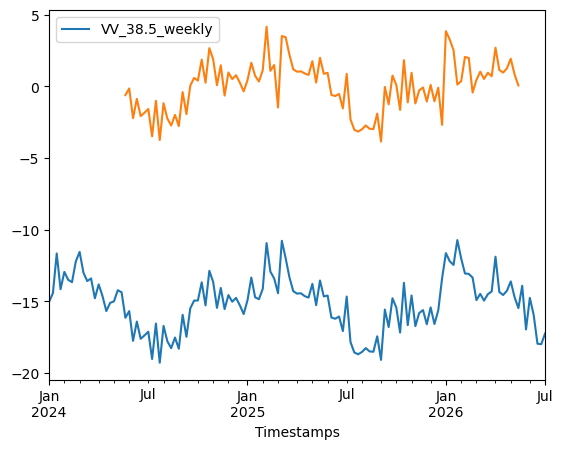

In [386]:
s1_weekly_2.plot()
backscatter_res.plot()

In [381]:
res3

{'lags': array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 'ccf': array([ 0.15245574,  0.16061241,  0.17482748,  0.17736685,  0.19267344,
         0.16710222,  0.09620385,  0.0472359 , -0.00285948, -0.06429427,
        -0.17456179, -0.32338245, -0.40087082, -0.46407333, -0.52009234,
        -0.57799413, -0.61582923, -0.60277624, -0.59174994, -0.54389507,
        -0.48699721]),
 'rho_critical': array([0.55697661, 0.56075198, 0.56449972, 0.56822177, 0.57191901,
        0.57559244, 0.57924269, 0.58287049, 0.58647638, 0.59006079,
        0.59362411, 0.59006079, 0.58647638, 0.58287049, 0.57924269,
        0.57559244, 0.57191901, 0.56822177, 0.56449972, 0.56075198,
        0.55697661]),
 'is_significant': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True,  True,  True,
         True, False, False]),
 'v_effective': array([12.64443604, 12.7645964

##### Iteración 4: backscatter y nivel observado segmentado en dos años